In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

# Importing Necessary Libraries:

In [37]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_hub as hub

from tensorflow.keras import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, TextVectorization, Embedding, GlobalMaxPool1D, LSTM, GRU, Conv1D, Bidirectional, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# importing and Pre-Processing The Data:

In [3]:
df = pd.read_csv("IMDB Dataset.csv")

In [4]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
df.shape

(50000, 2)

In [6]:
df["sentiment"].value_counts()

positive    25000
negative    25000
Name: sentiment, dtype: int64

In [7]:
# Viewing 10 Random Reviews:
start_index = random.randint(0, len(df)-10)

for row in df[start_index : start_index+10].itertuples():
    _, review, sentiment = row
    print(f"Sentiment: {sentiment}")
    print(f"Review:\n{review}\n")

Sentiment: negative
Review:
Such great actors such a disappointment. Marlon Brando plays and awful character, the movie is not funny at all, a subconscious message can be seen "IT IS A DAMN CRAP!!!", "IT SUUCKS SO BADLY!!", "THROW YOUR TV THROUGH WINDOW", and so on. It is simply disgusting and irksome. In addition to foolish plot, sense of humor, there is something else. The way the rooms are decorated, the colors. It makes me sick, everything is so colourful that it might cause epilepsy. Usually I do not care about the decoration in movie but this from "Free Money" made me angry. Avoid at all costs! "Free Money" - probably for Charlie Sheen, Sutherland and Brando, but a viewer gets nothing! One watches it at cost of sanity.

Sentiment: negative
Review:
<br /><br />This movie really has nothing going for it. With the Reverend played by Phillip Seymour Hoffman complaining about his constipation and other toilet humor in a 2.5 hour movie, you know that they made no cuts at all and left t

In [8]:
# Removing HTML Tags from Reviews:
df["review"] = df["review"].replace({'<.*?>': ''}, regex = True)

In [9]:
# Viewing 10 Random Reviews:
start_index = random.randint(0, len(df)-10)

for row in df[start_index : start_index+10].itertuples():
    _, review, sentiment = row
    print(f"Sentiment: {sentiment}")
    print(f"Review:\n{review}\n")

Sentiment: negative
Review:
I saw this cartoon accidentally on television one night when I couldn't get to sleep. It didn't help in the slightest. I found myself staring up at the ceiling, trying to forget that face. I could quite happily never see this cartoon again, simply because of that face.Now, don't get me wrong - I love fairy tales and nursery rhymes as much as anyone. But this twisted and terrifying rendition simply is disturbing. It is mainly the cruel laughter, and the exaggerated features that terrify me, and I still have nightmares because of it. Please, I urge you not to allow your children to see this. It is far, FAR too scary. Please, I pray you, keep it away.

Sentiment: positive
Review:
This is without a doubt the greatest film ever made. It is nearly incomprehensible even with many repeated viewings in an attempt to figure out what exactly's going on. The film was almost entirely improvised and includes random musical numbers, commercials, contests one enters by mail

In [10]:
# Changing Sentiment to Numerical Form:
df["sentiment"] = df["sentiment"].map({"positive": 1, "negative": 0})

In [11]:
df["sentiment"].value_counts()

1    25000
0    25000
Name: sentiment, dtype: int64

# Train Test Split:

In [12]:
train_reviews, test_reviews, train_labels, test_labels = train_test_split(df["review"].to_numpy(),
                                                                         df["sentiment"].to_numpy(),
                                                                         test_size= 0.2,
                                                                         random_state= 42)

In [13]:
train_reviews.shape, test_reviews.shape, train_labels.shape, test_labels.shape

((40000,), (10000,), (40000,), (10000,))

In [14]:
train_reviews[0], train_labels[0]

('That\'s what I kept asking myself during the many fights, screaming matches, swearing and general mayhem that permeate the 84 minutes. The comparisons also stand up when you think of the one-dimensional characters, who have so little depth that it is virtually impossible to care what happens to them. They are just badly written cyphers for the director to hang his multicultural beliefs on, a topic that has been done much better in other dramas both on TV and the cinema.I must confess, I\'m not really one for spotting bad performances during a film, but it must be said that Nichola Burley (as the heroine\'s slutty best friend) and Wasim Zakir (as the nasty, bullying brother) were absolutely terrible. I don\'t know what acting school they graduated from, but if I was them I\'d apply for a full refund post haste. Only Samina Awan in the lead role manages to impress in a cast of so-called British talent that we\'ll probably never hear from again. At least, that\'s the hope. Next time, hi

# Text Vectorization:

# Token Embedding Using Pre-Trained Embedding:

In [28]:
embedding_layer = hub.KerasLayer(handle= "https://www.kaggle.com/models/google/universal-sentence-encoder/tensorFlow2/universal-sentence-encoder/2",
                                       input_shape= [], # shape of inputs coming to our model (Variable Length Input, That's why empty vector as input shape)
                                       dtype= tf.string,
                                       trainable= False,
                                       name= "USE")

# Creating Data Pipelines:

In [30]:
train_data = tf.data.Dataset.from_tensor_slices(train_reviews)
train_target = tf.data.Dataset.from_tensor_slices(train_labels)
train_dataset = tf.data.Dataset.zip((train_data, train_target)).batch(32).prefetch(tf.data.AUTOTUNE)

test_data = tf.data.Dataset.from_tensor_slices(test_reviews)
test_target = tf.data.Dataset.from_tensor_slices(test_labels)
test_dataset = tf.data.Dataset.zip((test_data, test_target)).batch(32).prefetch(tf.data.AUTOTUNE)

# Creating Model Using Pre-Trained Embedding:

In [34]:
tf.random.set_seed(42)

model = Sequential()
model.add(embedding_layer)
#model.add(LSTM(64, activation= "relu"))
model.add(Dense(32, activation= "relu"))
model.add(Dense(1, activation= "sigmoid"))

# Compiling The Model:
model.compile(optimizer= Adam(),
             loss= BinaryCrossentropy(),
             metrics= ["accuracy"])

# Fitting The Model:
history = model.fit(train_dataset,
                   validation_data= test_dataset,
                   epochs= 5)

Epoch 1/5



1250/1250 [==============================] - 127s 76ms/step - loss: 0.3621 - accuracy: 0.8479 - val_loss: 0.3246 - val_accuracy: 0.8592
Epoch 2/5
1250/1250 [==============================] - 91s 73ms/step - loss: 0.3223 - accuracy: 0.8608 - val_loss: 0.3212 - val_accuracy: 0.8609
Epoch 3/5
1250/1250 [==============================] - 95s 76ms/step - loss: 0.3186 - accuracy: 0.8621 - val_loss: 0.3194 - val_accuracy: 0.8608
Epoch 4/5
1250/1250 [==============================] - 93s 74ms/step - loss: 0.3156 - accuracy: 0.8631 - val_loss: 0.3175 - val_accuracy: 0.8619
Epoch 5/5
1250/1250 [==============================] - 85s 68ms/step - loss: 0.3127 - accuracy: 0.8640 - val_loss: 0.3161 - val_accuracy: 0.8614


# Model Evaluation:

In [35]:
model_pred_probs = model.predict(test_reviews)
model_pred_probs

313/313 [==============================] - 18s 55ms/step


array([[0.64678377],
       [0.96759546],
       [0.0195169 ],
       ...,
       [0.50009626],
       [0.05279183],
       [0.96503794]], dtype=float32)

In [36]:
model_preds = tf.squeeze(tf.round(model_pred_probs))
model_preds

<tf.Tensor: shape=(10000,), dtype=float32, numpy=array([1., 1., 0., ..., 1., 0., 1.], dtype=float32)>

In [38]:
print(classification_report(test_labels, model_preds))

              precision    recall  f1-score   support

           0       0.85      0.88      0.86      4961
           1       0.87      0.85      0.86      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



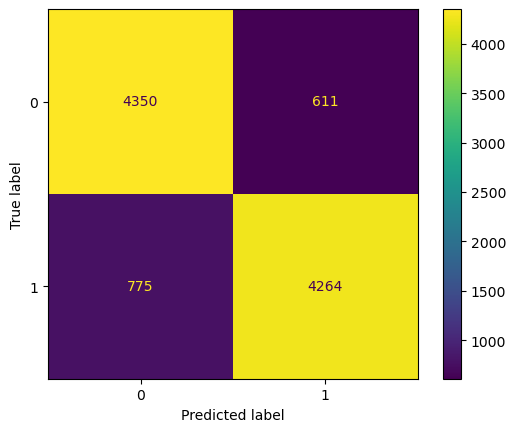

In [40]:
cm = confusion_matrix(test_labels, model_preds)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()